# Model Comparison — All 4 Algorithms
**Run this notebook LAST, after all 4 member notebooks are executed.**

Compares: **Random Forest · XGBoost · CatBoost · LightGBM**  
Dataset: NSL-KDD | Training: SMOTE-balanced | Test: real-world distribution

All models were tuned with:
- RandomizedSearchCV (50 iterations) + GridSearchCV (fine-grained)
- 5-fold Stratified Cross-Validation throughout
- Scoring: F1 (attack detection optimised)

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 2. Load Results from All 4 Members

In [3]:
result_files = [
    'results_random_forest.csv',
    'results_xgboost.csv',
    'results_catboost.csv',
    'results_lightgbm.csv',
]

dfs = []
for fname in result_files:
    path = os.path.join('.', fname)
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))
        print(f'Loaded : {fname}')
    else:
        print(f'MISSING: {fname} — run the member notebook first.')

results_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f'\nTotal algorithms loaded: {len(dfs)}')

Loaded : results_random_forest.csv
Loaded : results_xgboost.csv
Loaded : results_catboost.csv
Loaded : results_lightgbm.csv

Total algorithms loaded: 4


## 3. Manual Fallback — Paste Your Results Here If CSVs Are Missing

In [4]:
# UNCOMMENT and fill in your actual values if CSVs are not yet available

# results_df = pd.DataFrame([
#     {'Algorithm':'Random Forest','Type':'Supervised',
#      'Accuracy':0.00,'Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':0.00,
#      'CV F1 Mean':0.00,'CV F1 Std':0.00},
#     {'Algorithm':'XGBoost','Type':'Supervised',
#      'Accuracy':0.00,'Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':0.00,
#      'CV F1 Mean':0.00,'CV F1 Std':0.00},
#     {'Algorithm':'CatBoost','Type':'Supervised',
#      'Accuracy':0.00,'Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':0.00,
#      'CV F1 Mean':0.00,'CV F1 Std':0.00},
#     {'Algorithm':'LightGBM','Type':'Supervised',
#      'Accuracy':0.00,'Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':0.00,
#      'CV F1 Mean':0.00,'CV F1 Std':0.00},
# ])
print('Manual fallback ready.')

Manual fallback ready.


## 4. Full Comparison Table

In [5]:
display_cols = [c for c in ['Algorithm','Type','Accuracy','Precision',
                             'Recall','F1 Score','ROC-AUC',
                             'CV F1 Mean','CV F1 Std']
                if c in results_df.columns]

print('=== Full Comparison Table ===')
print(results_df[display_cols].to_string(index=False))

=== Full Comparison Table ===
    Algorithm       Type  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV F1 Mean  CV F1 Std
Random Forest Supervised    0.7607     0.7976  0.9394    0.8627   0.4785      0.8846     0.0073
      XGBoost Supervised    0.7675     0.8086  0.9295    0.8648   0.4810      0.8882     0.0060
     CatBoost Supervised    0.7664     0.8084  0.9281    0.8641   0.4656      0.9063     0.0064
     LightGBM Supervised    0.6851     0.7970  0.8138    0.8053   0.4855      0.8988     0.0080


## 5. F1 Score Bar Chart

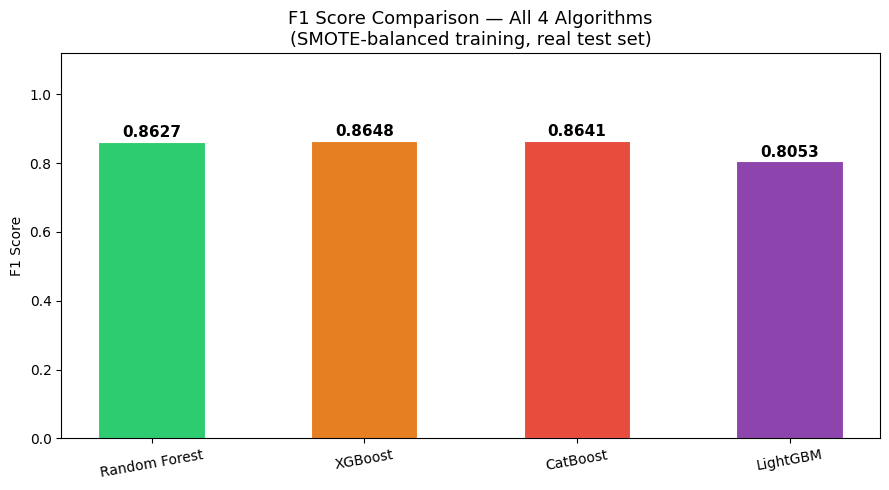

In [6]:
algo_colors = {
    'Random Forest': '#2ecc71',
    'XGBoost'      : '#e67e22',
    'CatBoost'     : '#e74c3c',
    'LightGBM'     : '#8e44ad'
}
colors  = [algo_colors.get(a,'#95a5a6') for a in results_df['Algorithm']]
f1_vals = pd.to_numeric(results_df['F1 Score'], errors='coerce')

plt.figure(figsize=(9, 5))
bars = plt.bar(results_df['Algorithm'], f1_vals,
               color=colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, f1_vals):
    if not pd.isna(val):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
plt.title('F1 Score Comparison — All 4 Algorithms\n(SMOTE-balanced training, real test set)',
          fontsize=13)
plt.ylabel('F1 Score')
plt.ylim(0, 1.12)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('comparison_f1.png', dpi=150)
plt.show()

## 6. Grouped Bar Chart — Precision, Recall, F1

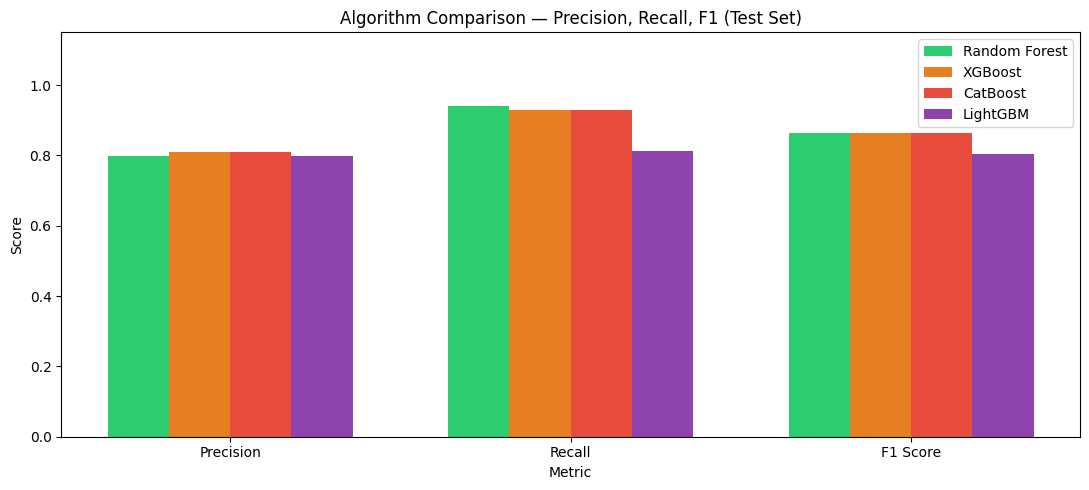

In [7]:
metrics   = ['Precision','Recall','F1 Score']
x         = np.arange(len(metrics))
bar_width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [pd.to_numeric(row.get(m, np.nan), errors='coerce') for m in metrics]
    ax.bar(x + i*bar_width, vals, bar_width,
           label=row['Algorithm'],
           color=algo_colors.get(row['Algorithm'],'#95a5a6'))

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Algorithm Comparison — Precision, Recall, F1 (Test Set)')
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig('comparison_grouped_bar.png', dpi=150)
plt.show()

## 7. ROC-AUC Comparison

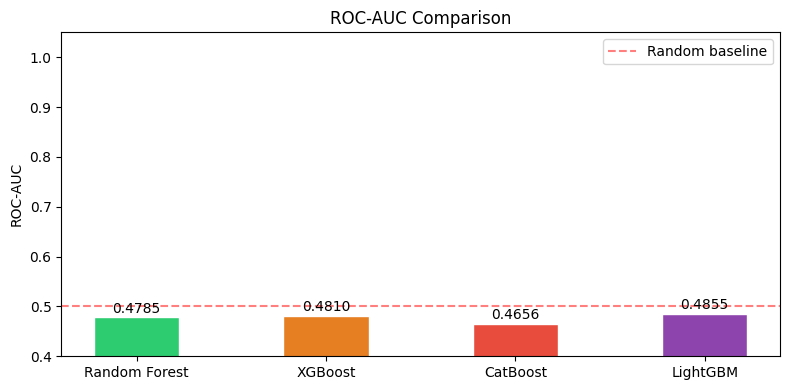

In [8]:
roc_df = results_df.copy()
roc_df['ROC-AUC'] = pd.to_numeric(roc_df['ROC-AUC'], errors='coerce')
roc_df = roc_df.dropna(subset=['ROC-AUC'])

if not roc_df.empty:
    c = [algo_colors.get(a,'#95a5a6') for a in roc_df['Algorithm']]
    plt.figure(figsize=(8, 4))
    bars = plt.bar(roc_df['Algorithm'], roc_df['ROC-AUC'],
                   color=c, edgecolor='white', width=0.45)
    for bar, val in zip(bars, roc_df['ROC-AUC']):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
    plt.ylim(0.4, 1.05)
    plt.ylabel('ROC-AUC')
    plt.title('ROC-AUC Comparison')
    plt.legend()
    plt.tight_layout()
    plt.savefig('comparison_roc_auc.png', dpi=150)
    plt.show()

## 8. CV F1 with Error Bars

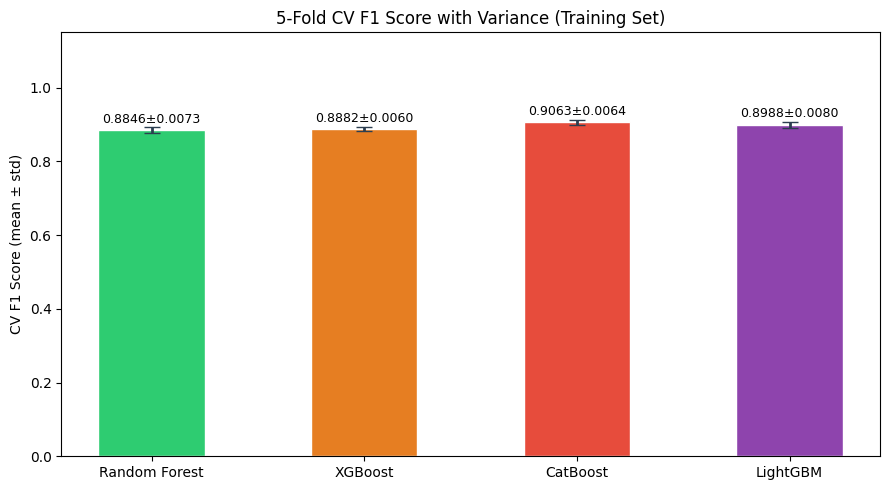

In [9]:
if 'CV F1 Mean' in results_df.columns and 'CV F1 Std' in results_df.columns:
    cv_means = pd.to_numeric(results_df['CV F1 Mean'], errors='coerce')
    cv_stds  = pd.to_numeric(results_df['CV F1 Std'],  errors='coerce')

    plt.figure(figsize=(9, 5))
    bars = plt.bar(results_df['Algorithm'], cv_means,
                   yerr=cv_stds, capsize=6,
                   color=colors, edgecolor='white', width=0.5,
                   error_kw={'linewidth':2, 'ecolor':'#2c3e50'})
    for bar, mean, std in zip(bars, cv_means, cv_stds):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + std + 0.005,
                 f'{mean:.4f}±{std:.4f}',
                 ha='center', va='bottom', fontsize=9)
    plt.ylabel('CV F1 Score (mean ± std)')
    plt.title('5-Fold CV F1 Score with Variance (Training Set)')
    plt.ylim(0, 1.15)
    plt.tight_layout()
    plt.savefig('comparison_cv_f1_errorbars.png', dpi=150)
    plt.show()

## 9. Performance Heatmap

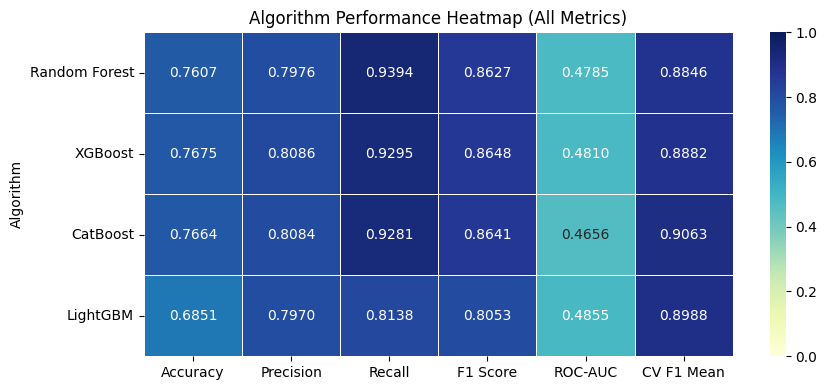

In [10]:
hmap_metrics = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC','CV F1 Mean']
hmap_metrics = [m for m in hmap_metrics if m in results_df.columns]
hmap = results_df.set_index('Algorithm')[hmap_metrics]\
                 .apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(9, 4))
sns.heatmap(hmap, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('Algorithm Performance Heatmap (All Metrics)')
plt.tight_layout()
plt.savefig('comparison_heatmap.png', dpi=150)
plt.show()

## 10. Discussion Points for Report

In [11]:
print("""
=== KEY DISCUSSION POINTS FOR REPORT ===

DATASET & CLASS IMBALANCE
  Raw: 886 normal vs 3544 attack (80% attack).
  Without correction, models predict 'attack' for everything.
  SMOTE generated synthetic normal samples on the TRAINING SET only.
  Test set was kept untouched (real-world distribution).

RANDOM FOREST
  Pros : Robust ensemble, interpretable feature importance,
         handles high dimensionality well, low variance.
  Cons : Slower inference than boosting methods, large model size.

XGBOOST
  Pros : Typically best on tabular data, built-in L1/L2 regularisation,
         SHAP explainability, handles missing values natively.
  Cons : Many hyperparameters, can overfit without careful tuning.

CATBOOST
  Pros : Ordered boosting prevents target leakage, symmetric trees
         are fast at prediction time, minimal preprocessing needed,
         strong default parameters — often competitive with less tuning.
  Cons : Slower training than LightGBM on large datasets.

LIGHTGBM
  Pros : Leaf-wise growth finds better splits; fastest training of the
         four; histogram-based splitting; excellent on large datasets;
         dart boosting adds dropout regularisation.
  Cons : Leaf-wise growth can overfit on small datasets if num_leaves
         is too large; requires more tuning than CatBoost.

SMOTE EFFECTIVENESS
  After SMOTE: normal precision/recall should improve significantly
  compared to without SMOTE (which showed recall=0.02 for normal).
  Trade-off: slightly lower overall accuracy but much better balance.

HYPERPARAMETER TUNING
  Two-phase approach: RandomizedSearchCV (wide exploration) followed
  by GridSearchCV (refinement) proved more efficient than grid search
  alone. 5-fold CV ensured stable estimates.

METRICS IN CONTEXT
  Recall (Normal): critical — missing a normal connection mislabelled
    as attack wastes analyst time (false alarm).
  Recall (Attack): critical — missing a real attack is dangerous.
  F1: balances precision and recall — best single summary metric.
  ROC-AUC: threshold-independent, measures discrimination quality.

FUTURE WORK
  - Multi-class classification (DoS vs Probe vs R2L vs U2R vs normal).
  - Stacking ensemble: combine all 4 model outputs.
  - Online learning for real-time stream anomaly detection.
  - Test on CICIDS-2017 / UNSW-NB15 for generalisability.
""")


=== KEY DISCUSSION POINTS FOR REPORT ===

DATASET & CLASS IMBALANCE
  Raw: 886 normal vs 3544 attack (80% attack).
  Without correction, models predict 'attack' for everything.
  SMOTE generated synthetic normal samples on the TRAINING SET only.
  Test set was kept untouched (real-world distribution).

RANDOM FOREST
  Pros : Robust ensemble, interpretable feature importance,
         handles high dimensionality well, low variance.
  Cons : Slower inference than boosting methods, large model size.

XGBOOST
  Pros : Typically best on tabular data, built-in L1/L2 regularisation,
         SHAP explainability, handles missing values natively.
  Cons : Many hyperparameters, can overfit without careful tuning.

CATBOOST
  Pros : Ordered boosting prevents target leakage, symmetric trees
         are fast at prediction time, minimal preprocessing needed,
         strong default parameters — often competitive with less tuning.
  Cons : Slower training than LightGBM on large datasets.

LIGHTGBM


## 11. Export Final Table

In [12]:
results_df.to_csv('final_comparison_table.csv', index=False)
print('Saved: final_comparison_table.csv')
print()
print(results_df[display_cols].to_string(index=False))

Saved: final_comparison_table.csv

    Algorithm       Type  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV F1 Mean  CV F1 Std
Random Forest Supervised    0.7607     0.7976  0.9394    0.8627   0.4785      0.8846     0.0073
      XGBoost Supervised    0.7675     0.8086  0.9295    0.8648   0.4810      0.8882     0.0060
     CatBoost Supervised    0.7664     0.8084  0.9281    0.8641   0.4656      0.9063     0.0064
     LightGBM Supervised    0.6851     0.7970  0.8138    0.8053   0.4855      0.8988     0.0080
